# install neceassary library

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
df = sns.load_dataset("taxis")
df.head()


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [4]:
df.shape

(6433, 14)

In [5]:
df = df[["distance","fare"]]
df.head()

,distance,fare
0,1.60,7.0
1,0.79,5.0
2,1.37,7.5
3,7.70,27.0
4,2.16,9.0


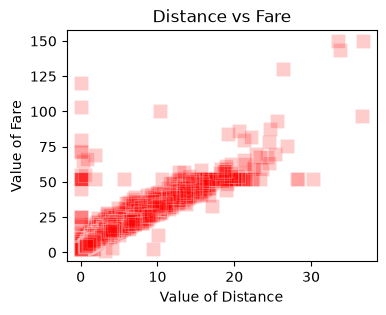

In [6]:
plt.figure(figsize=(4,3))
sns.scatterplot(x=df["distance"],y=df["fare"],color="r",marker="s",s=100,alpha=.2)
plt.xlabel("Value of Distance")
plt.ylabel("Value of Fare")
plt.title("Distance vs Fare")
plt.show()

from the given visualization we conclude that the value of fare is increased in a continous manner when the value of distance is increased. It goes from 0-30 but after 30 we sew some flactuations over fare and distance.


In [7]:
df.isna().sum()

distance    0
fare        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(2978)

the given dataset donot have any NaN value but have a big number of duplicate value and we need to drop them, as because the proposed model will not be baised

# Data Clean

In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()


np.int64(0)

In [11]:
df.info()


<class 'pandas.DataFrame'>
Index: 3455 entries, 0 to 6432
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   distance  3455 non-null   float64
 1   fare      3455 non-null   float64
dtypes: float64(2)
memory usage: 81.0 KB


In [12]:
df.shape

(3455, 2)

In [13]:
df.describe()

,distance,fare
count,3455.000000,3455.000000
mean,4.365847,17.424420
std,4.617425,13.648461
min,0.000000,1.000000
25%,1.440000,8.500000
50%,2.680000,13.000000
75%,5.320000,21.000000
max,36.700000,150.000000


<Axes: >

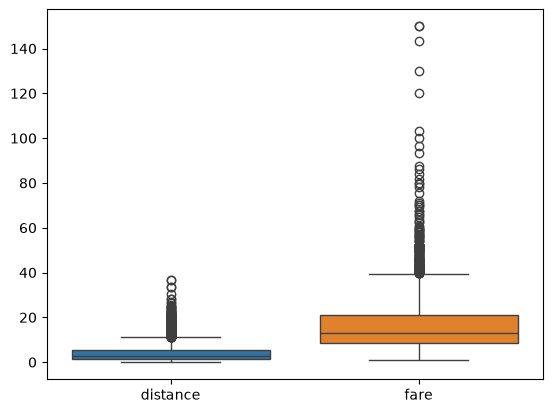

In [14]:
sns.boxplot(df)

# Outlier Removal via IQR


In [15]:
def removing_outliers(df, cols):
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        df = df[(df[col] >= lower) & (df[col] <= upper)]

    return df

df1 = removing_outliers(df,["fare"])

In [16]:
df1.shape

(3198, 2)

<Axes: >

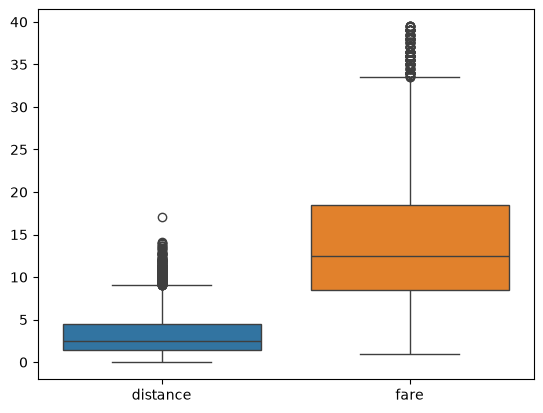

In [17]:
sns.boxplot(df1)

In [18]:
df1.shape

(3198, 2)

# Feature Selection & Split

In [19]:
x = df1[["distance"]] 
y = df1[["fare"]]

In [20]:
# split the dataset 
from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=.2,random_state=42)

In [21]:
xtrain.head()

,distance
6022,9.00
4822,8.60
642,0.90
1486,3.37
4960,4.50


In [22]:
ytrain.head()

,fare
6022,33.65
4822,26.50
642,7.50
1486,12.50
4960,14.50


# Model Implementation


In [23]:
# model implement
from sklearn.linear_model import LinearRegression

# instance of object
lr = LinearRegression()

linear_model = lr.fit(xtrain,ytrain)
linear_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[2.73]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['distance']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[5.23]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [24]:
#check train score
linear_model.score(xtrain,ytrain)

0.879947585972501

In [25]:
#check test score
linear_model.score(xtest,ytest)

0.8900081200068146

In [26]:
linear_model.predict([[43]])

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[122.41341609]])

In [27]:
y_pred = linear_model.predict(xtest)

# Evaluation & Predictions

In [28]:
# evaluate the model
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [29]:
#evaluate the model 
r_sc = r2_score(ytest,y_pred)
r_sc

0.8900081200068146

In [30]:
#cost calculation
mae = mean_absolute_error(ytest,y_pred)
mae

2.00707271032322

In [31]:
mse = mean_squared_error(ytest,y_pred)
mse

7.530282212585519